<a href="https://www.kaggle.com/code/sonawanelalitsunil/lifestyle-health-risk-analysis-ml-100?scriptVersionId=269295938" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lifestyle-and-health-risk-prediction/Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv


## Title:
Lifestyle Health Risk Analysis

## Description:
This project focuses on predicting potential health risks based on individuals’ lifestyle patterns. It uses data such as age, gender, body metrics (like BMI, weight, and height), heart rate statistics, workout duration, calorie expenditure, water intake, and other lifestyle habits. By applying machine learning algorithms, the system identifies patterns that correlate lifestyle behaviors with possible health risks such as obesity, cardiovascular conditions, or poor fitness levels. The goal is to help individuals and healthcare professionals gain actionable insights into preventive care and promote healthier living through data-driven predictions.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/lifestyle-and-health-risk-prediction/Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")

In [3]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [4]:
df.tail()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
4995,42,75,187,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39,86,183,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48,56,194,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34,109,148,medium,9.9,medium,no,no,yes,doctor,49.8,low
4999,72,47,149,high,6.3,medium,no,no,yes,driver,21.2,low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [6]:
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [7]:
df.isnull().sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

age               int64
weight            int64
height            int64
exercise         object
sleep           float64
sugar_intake     object
smoking          object
alcohol          object
married          object
profession       object
bmi             float64
health_risk      object
dtype: object

In [10]:
df.shape

(5000, 12)

In [11]:
df.describe().loc[['mean','min','max']]

,age,weight,height,sleep,bmi
mean,48.8056,77.3592,171.9332,6.99706,26.84388
min,18.0000,45.0000,145.0000,3.00000,11.40000
max,79.0000,109.0000,199.0000,10.00000,51.40000


In [12]:
df.columns

Index(['age', 'weight', 'height', 'exercise', 'sleep', 'sugar_intake',
       'smoking', 'alcohol', 'married', 'profession', 'bmi', 'health_risk'],
      dtype='object')

## Data visualizations

In [13]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

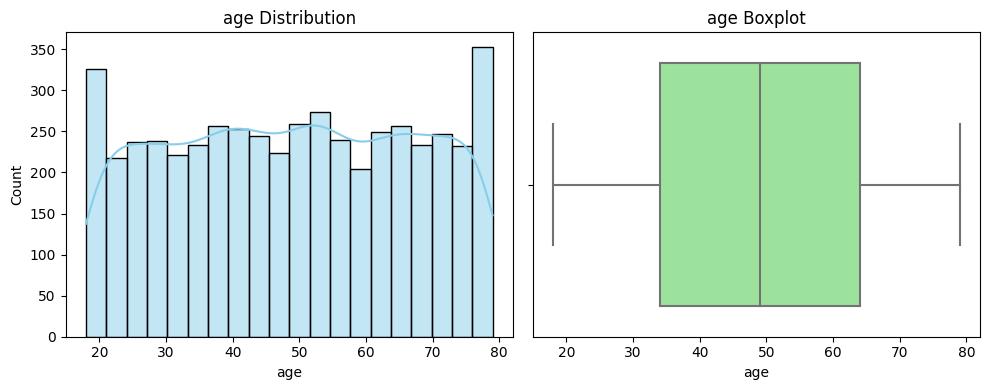

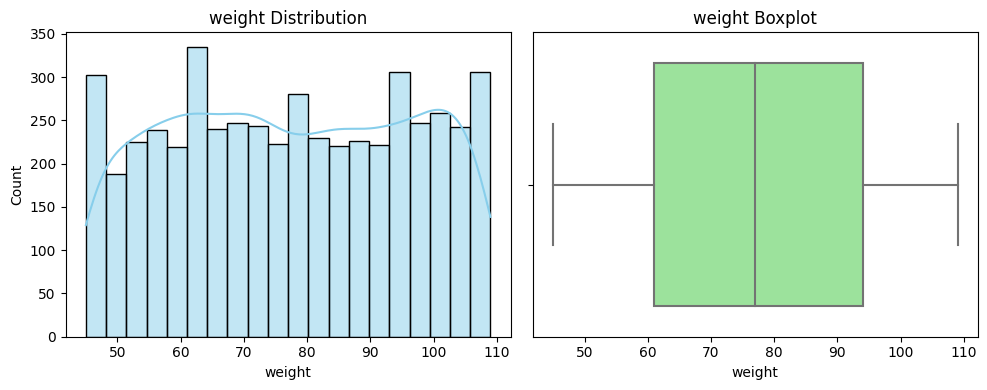

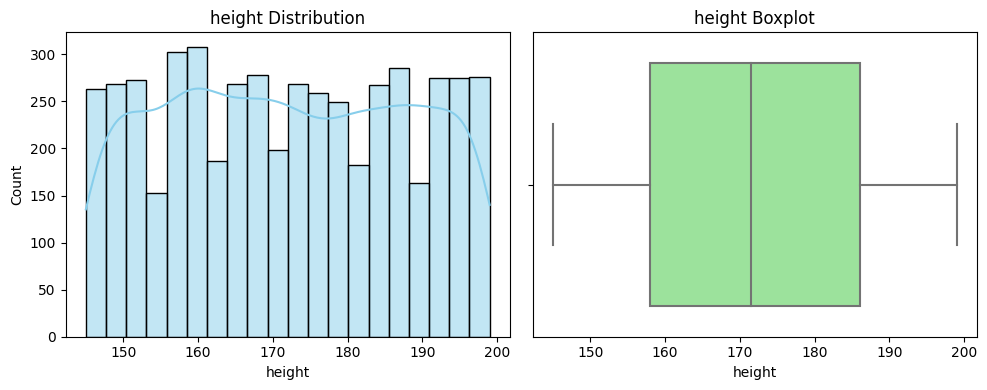

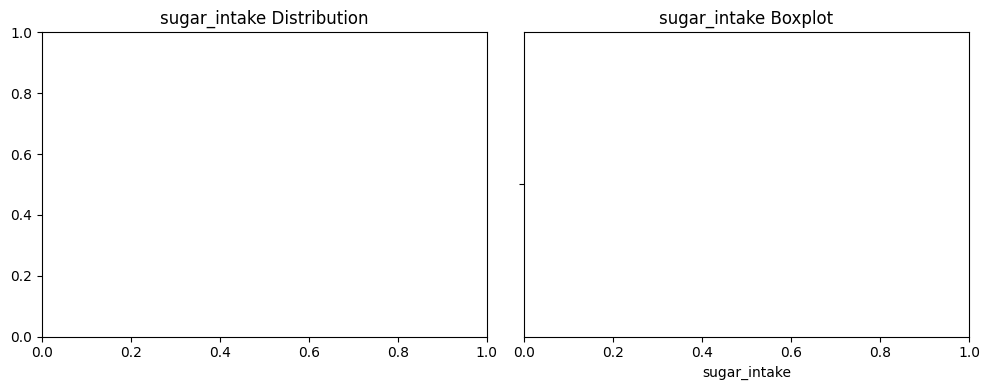

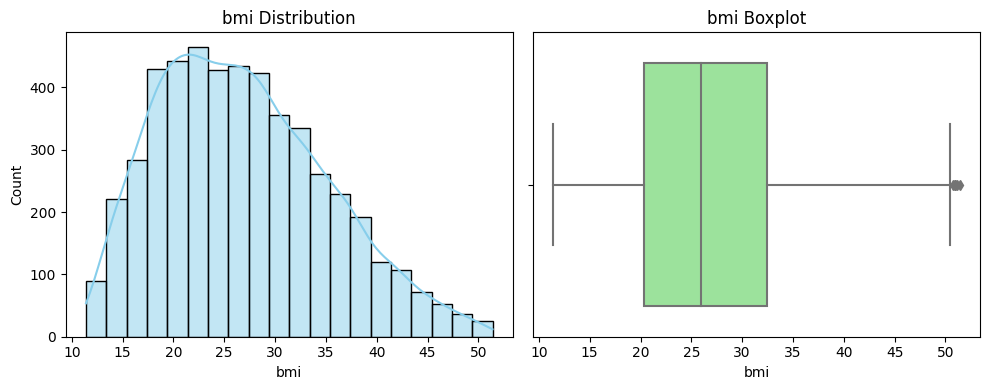

In [14]:
numerical_cols = ['age', 'weight', 'height', 'sugar_intake', 'bmi']

for col in numerical_cols:
    # Convert to numeric (forces errors to NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    plt.figure(figsize=(10, 4))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True, bins=20, color='skyblue')
    plt.title(f'{col} Distribution')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col].dropna(), color='lightgreen')
    plt.title(f'{col} Boxplot')
    
    plt.tight_layout()
    plt.show()


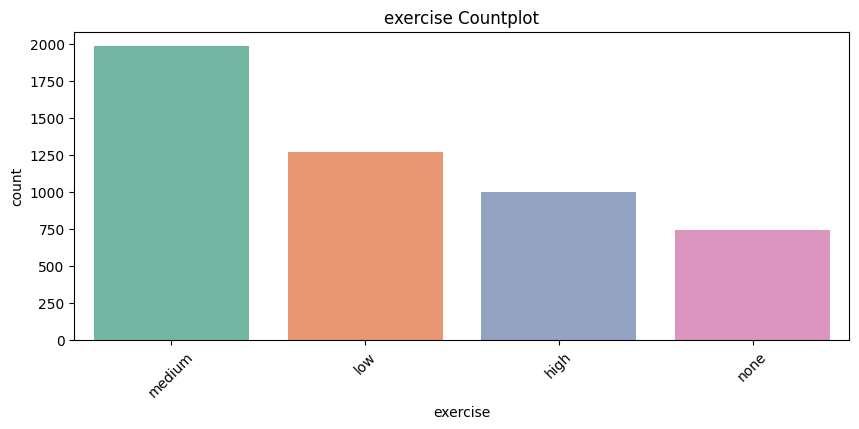

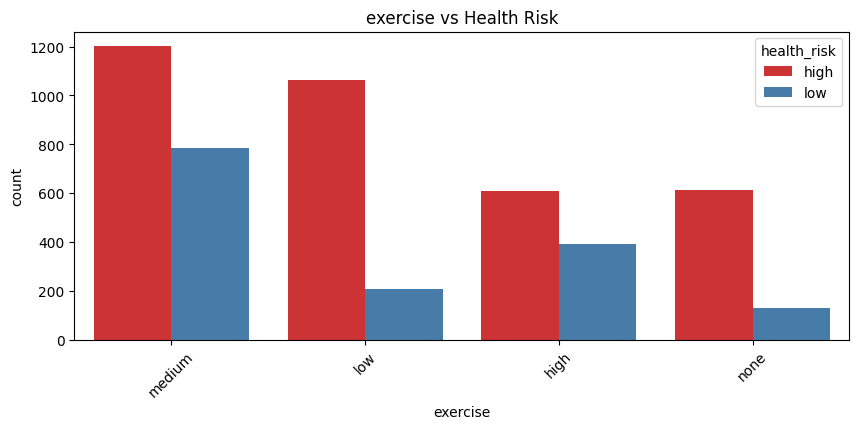

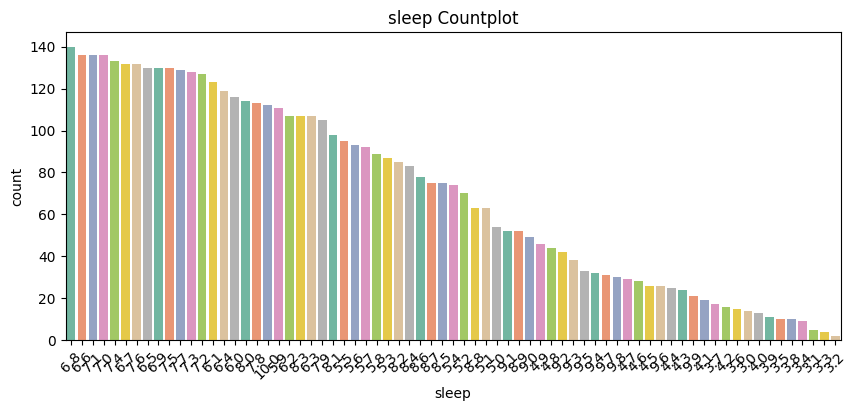

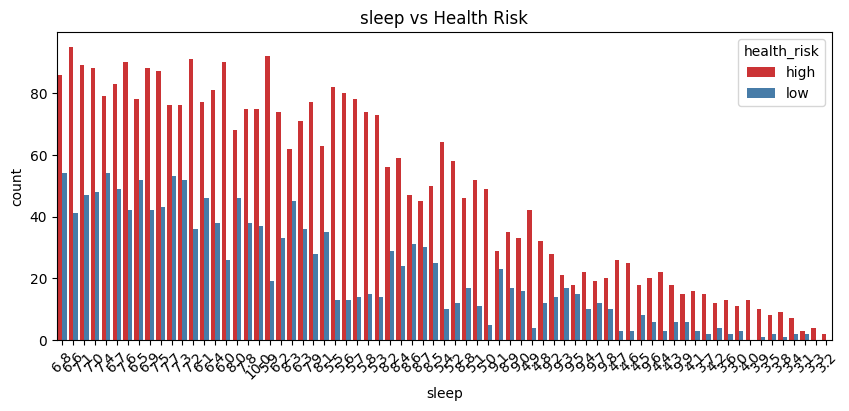

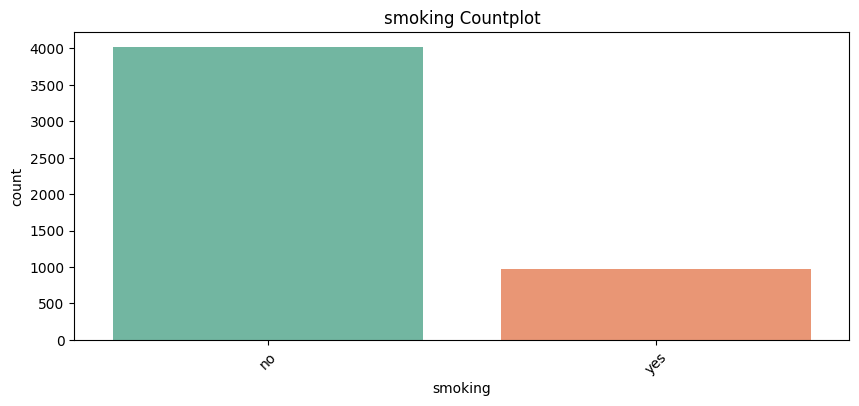

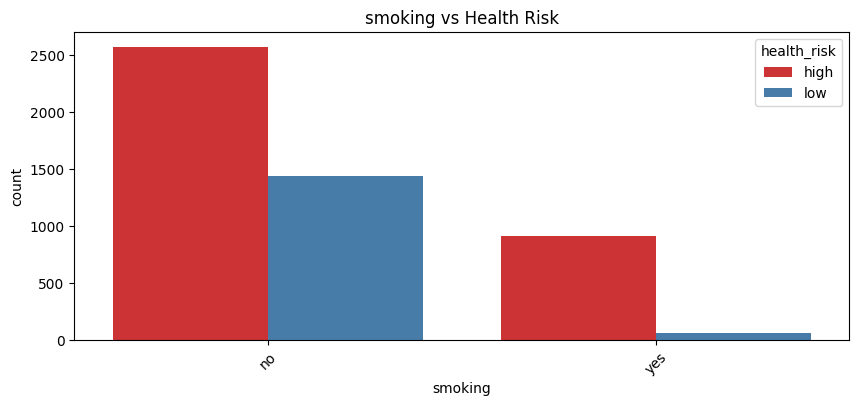

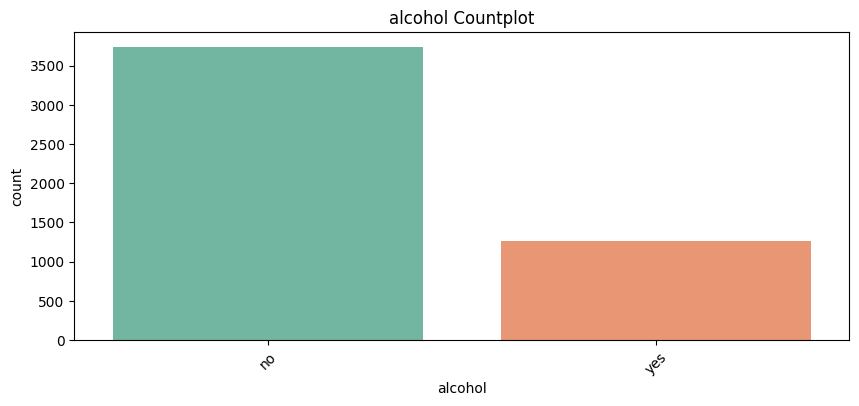

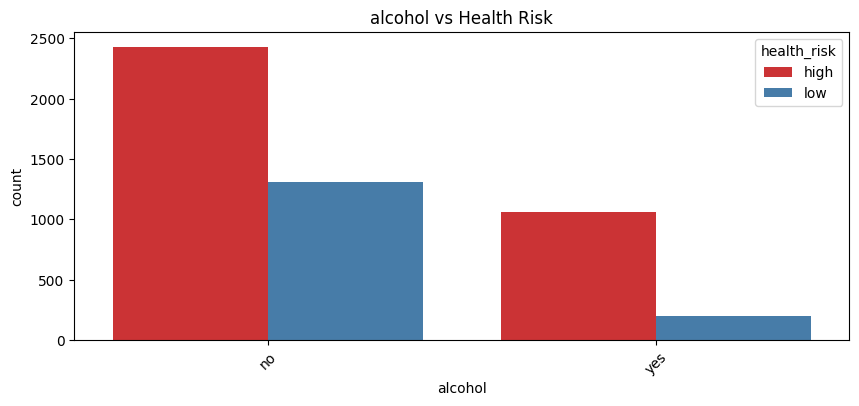

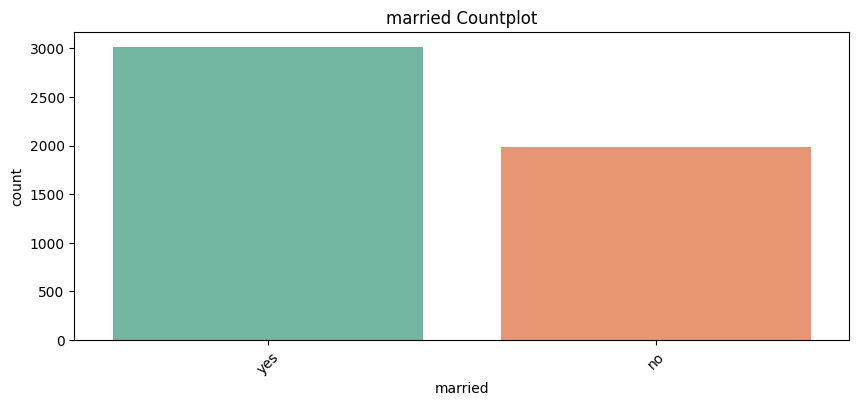

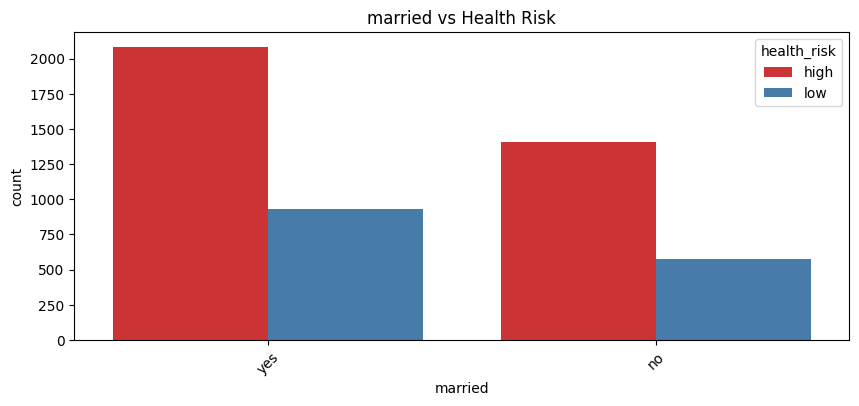

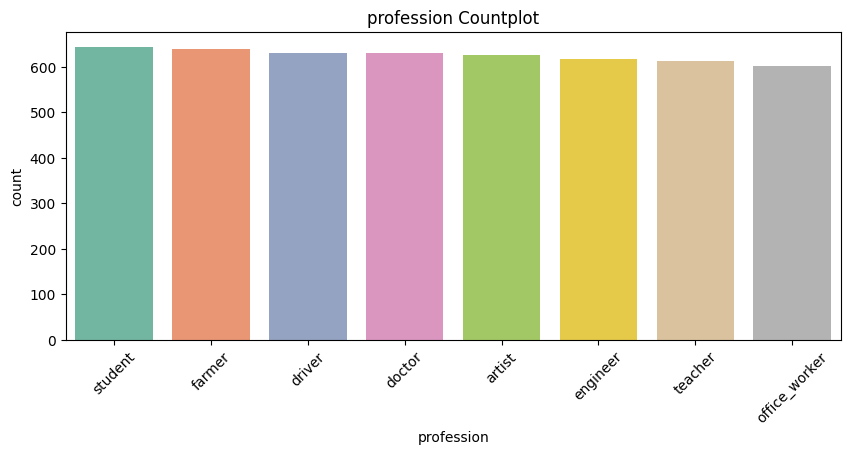

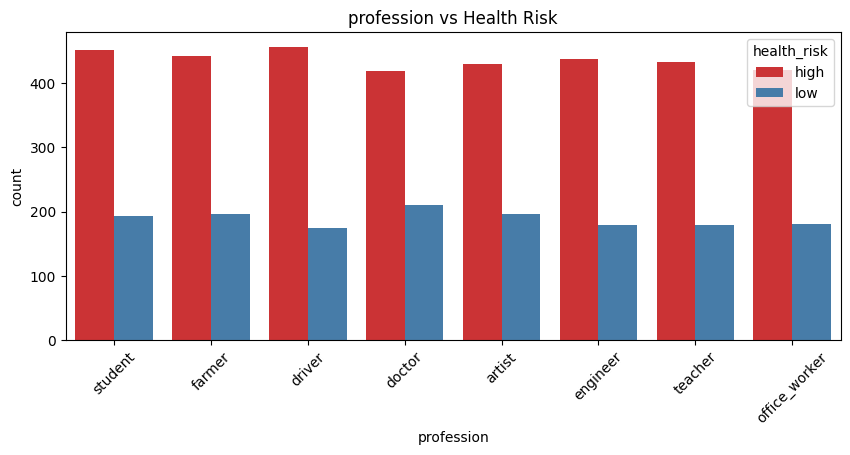

In [15]:
categorical_cols = ['exercise', 'sleep', 'smoking', 'alcohol', 'married', 'profession']

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    
    # Countplot
    sns.countplot(x=df[col], palette='Set2', order=df[col].value_counts().index)
    plt.title(f'{col} Countplot')
    plt.xticks(rotation=45)
    
    # Countplot vs health_risk
    plt.figure(figsize=(10, 4))
    sns.countplot(x=df[col], hue=df['health_risk'], palette='Set1', order=df[col].value_counts().index)
    plt.title(f'{col} vs Health Risk')
    plt.xticks(rotation=45)
    plt.show()

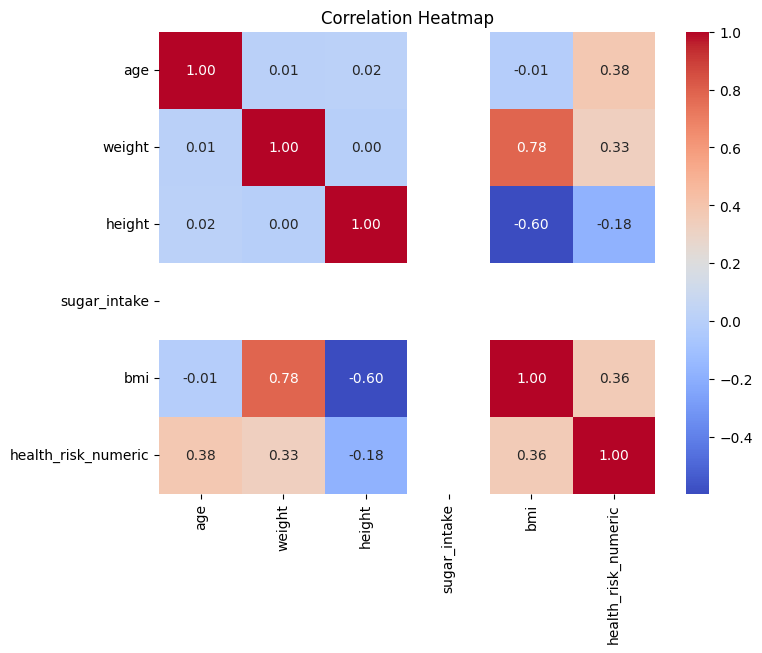

In [16]:
df['health_risk_numeric'] = df['health_risk'].map({'low': 0, 'medium': 1, 'high': 2})

# Ensure numeric columns are numeric
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols + ['health_risk_numeric']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

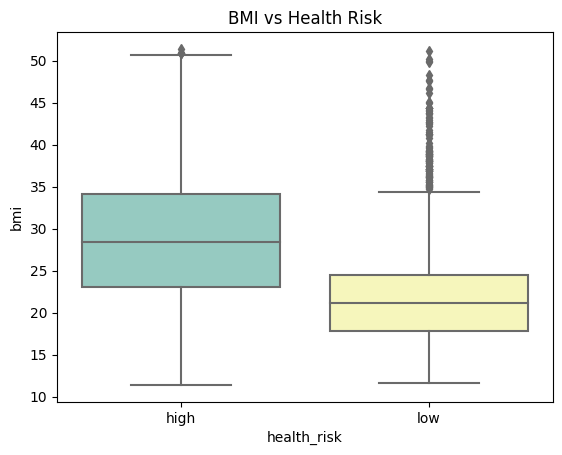

In [17]:
sns.boxplot(x='health_risk', y='bmi', data=df, palette='Set3')
plt.title('BMI vs Health Risk')
plt.show()


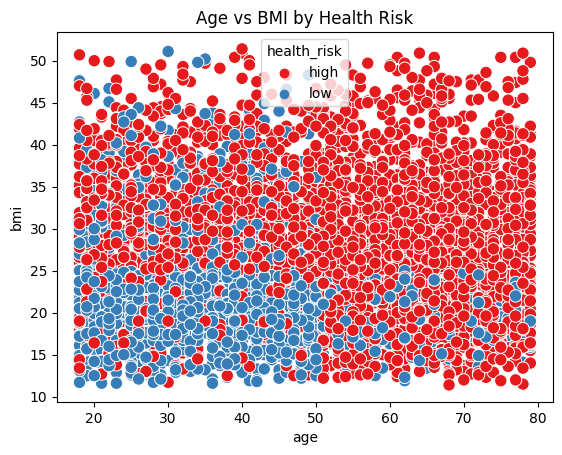

In [18]:
sns.scatterplot(x='age', y='bmi', hue='health_risk', data=df, palette='Set1', s=80)
plt.title('Age vs BMI by Health Risk')
plt.show()

## ML Algorithms

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

In [20]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
le = LabelEncoder()
for col in ['exercise','sugar_intake','smoking','alcohol','married','profession','health_risk']:
    df[col] = le.fit_transform(df[col])

scaler = MinMaxScaler()
scaled_cols = ['age','weight','height','sleep','bmi']
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

X = df.drop('health_risk', axis=1)
y = df['health_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": xgb.XGBClassifier(),
    "LightGBM": lgb.LGBMClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "GradientBoosting": GradientBoostingClassifier(),
    "ExtraTrees": ExtraTreesClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results.append((name, score))
    
pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

[LightGBM] [Info] Number of positive: 1218, number of negative: 2782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 527
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.304500 -> initscore=-0.825960
[LightGBM] [Info] Start training from score -0.825960
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Model,Accuracy
0,LogisticRegression,1.0
1,DecisionTree,1.0
2,RandomForest,1.0
3,XGBoost,1.0
4,LightGBM,1.0
5,SVM,1.0
6,KNN,1.0
7,NaiveBayes,1.0
8,GradientBoosting,1.0
9,ExtraTrees,1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       708
           1       1.00      1.00      1.00       292

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



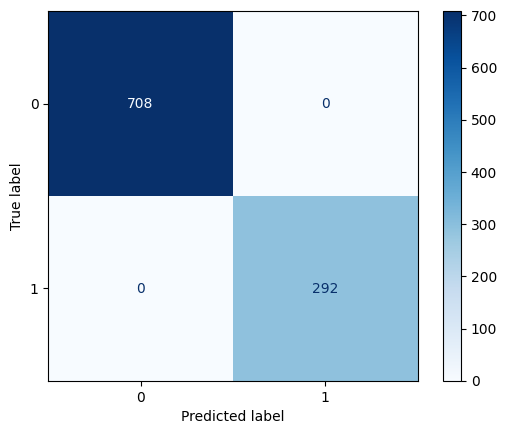

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model = RandomForestClassifier().fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       708
           1       1.00      1.00      1.00       292

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



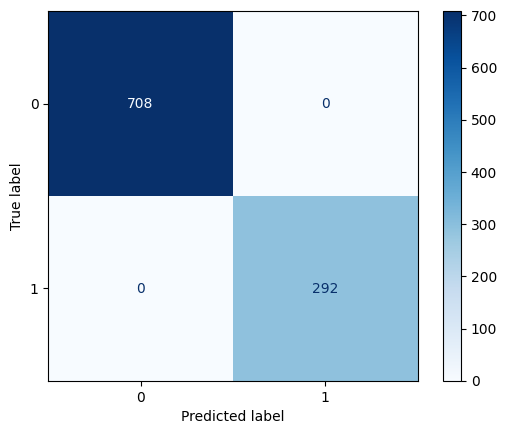

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model = RandomForestClassifier().fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

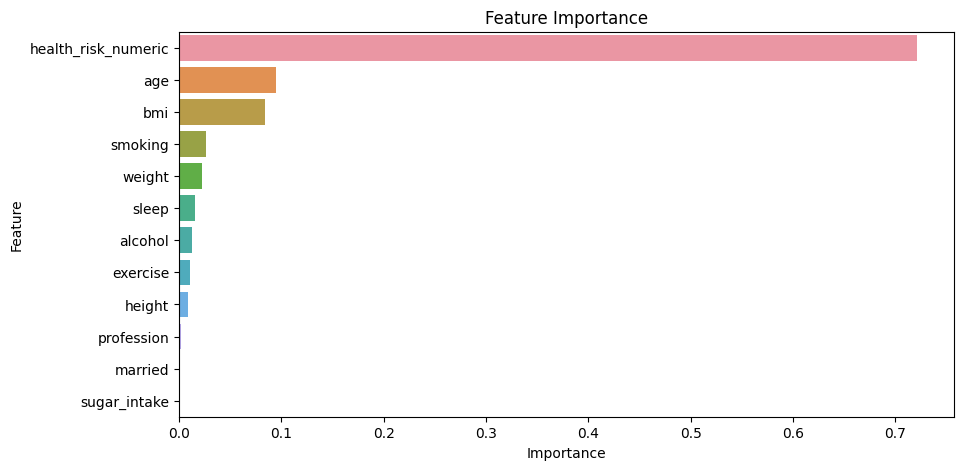

In [24]:
importances = best_model.feature_importances_
features = X.columns
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('Feature Importance')
plt.show()

## Thank you..pls upvote!!